In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

    Zomato

In [166]:
zomato = pd.read_csv('zomato.csv', encoding = 'latin-1')

In [167]:
zomato.shape

(9551, 21)

In [168]:
zomato.head(3)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270


In [169]:
zomato.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [170]:
# both locality verbose and locality seems to be same 
zomato['Locality Verbose'][0]

'Century City Mall, Poblacion, Makati City, Makati City'

In [171]:
zomato['Locality'][0]

'Century City Mall, Poblacion, Makati City'

In [172]:
zomato['Locality'].nunique()

1208

In [173]:
zomato['Locality Verbose'].unique()

array(['Century City Mall, Poblacion, Makati City, Makati City',
       'Little Tokyo, Legaspi Village, Makati City, Makati City',
       'Edsa Shangri-La, Ortigas, Mandaluyong City, Mandaluyong City',
       ..., 'Ko\x81ôuyolu, ÛÁstanbul', 'Kuruí_e\x81ôme, ÛÁstanbul',
       'Moda, ÛÁstanbul'], dtype=object)

In [174]:
zomato[(zomato['Locality'] == zomato['Locality Verbose'])]

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
9384,6113680,Restaurant Gordon Ramsay,215,London,"68 Royal Hospital Road, Chelsea, London SW3 4HP",Chelsea,Chelsea,-0.162092,51.485509,French,230,Pounds(£),No,No,No,No,4,4.7,Dark Green,Excellent,320
9386,6100054,Masala Zone,215,London,"48 Floral Street, Covent Garden, London WC2E 9DA",Covent Garden,Covent Garden,-0.123132,51.513196,"Indian, Curry",30,Pounds(£),Yes,No,No,No,2,4.1,Green,Very Good,316
9390,6102866,Hakkasan,215,London,"17 Bruton Street, Mayfair, London W1J 6QB",Mayfair,Mayfair,-0.144861,51.510342,"Chinese, Dim Sum",120,Pounds(£),Yes,No,No,No,4,4.8,Dark Green,Excellent,395
9391,6103868,Nobu,215,London,"15 Berkeley Street, Mayfair, London W1J 8DY",Mayfair,Mayfair,-0.143259,51.508811,"Japanese, Sushi",100,Pounds(£),Yes,No,No,No,4,4.4,Green,Very Good,311


In [175]:
zomato.sample(3)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
1408,311725,Big Jack's,1,Gurgaon,"DLF Phase 4, Gurgaon",DLF Phase 4,"DLF Phase 4, Gurgaon",77.085919,28.469703,"Continental, Burger, American",800,Indian Rupees(Rs.),No,Yes,No,No,2,3.5,Yellow,Good,129
5226,301820,Spicy Tadka,1,New Delhi,"BE 332, Hari Nagar Street 3, Mayapuri Phase 2,...",Mayapuri Phase 2,"Mayapuri Phase 2, New Delhi",77.119606,28.630817,"North Indian, Chinese",600,Indian Rupees(Rs.),No,Yes,No,No,2,3.5,Yellow,Good,24
7584,313282,Flavors of London,1,New Delhi,"K-131/2, Mahavir Nagar, Krishna Park, Main Out...",Tilak Nagar,"Tilak Nagar, New Delhi",77.085435,28.639606,"Desserts, Ice Cream, Fast Food",200,Indian Rupees(Rs.),No,No,No,No,1,0.0,White,Not rated,2


In [176]:
""" Here Locality verbose is redundant because locality has the information same as locality verbose
    and verbose is not well structured, so I will drop locality verbose """
zomato.drop(columns = ['Locality Verbose'], inplace = True)

In [177]:
zomato.sample(2)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
167,17315995,El Super Burrito,216,Cedar Rapids/Iowa City,"3300 Johnson Ave NW, Cedar Rapids, IA 52405",Cedar Rapids,-91.714800,41.974800,Mexican,10,Dollar($),No,No,No,No,1,4.1,Green,Very Good,190
9477,75026,Baobab Cafe & Grill,189,Pretoria,"Menlyn Shopping Centre, Level 1, Corner of Att...","Menlyn Shopping Centre, Menlyn",28.275005,-25.782735,"Cafe, Grill",410,Rand(R),No,No,No,No,4,4.0,Green,Very Good,235


In [178]:
zomato.dropna(subset = ['Cuisines'], inplace = True)

In [179]:
zomato.shape

(9542, 20)

    Working with json

In [180]:
# file1.json
file1 = pd.read_json('file1.json')

In [181]:
file1

,results_found,restaurants,results_shown,results_start,message,code,status
0,17151.0,"[{'restaurant': {'has_online_delivery': 1, 'ph...",20.0,1.0,NaN,NaN,NaN
1,4748.0,"[{'restaurant': {'has_online_delivery': 0, 'ph...",20.0,1.0,NaN,NaN,NaN
2,13786.0,"[{'restaurant': {'has_online_delivery': 0, 'ph...",20.0,1.0,NaN,NaN,NaN
3,10224.0,"[{'restaurant': {'has_online_delivery': 0, 'ph...",20.0,1.0,NaN,NaN,NaN
4,7039.0,"[{'restaurant': {'has_online_delivery': 0, 'ph...",20.0,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...
474,NaN,NaN,NaN,NaN,API limit exceeded,440.0,
475,NaN,NaN,NaN,NaN,API limit exceeded,440.0,
476,NaN,NaN,NaN,NaN,API limit exceeded,440.0,
477,NaN,NaN,NaN,NaN,API limit exceeded,440.0,


In [182]:
# filter the valid rows
valid_data1 = file1['restaurants'].dropna()
valid_data1= valid_data1[valid_data1.apply(lambda x: isinstance(x, list))]

In [183]:
valid_data1

0     [{'restaurant': {'has_online_delivery': 1, 'ph...
1     [{'restaurant': {'has_online_delivery': 0, 'ph...
2     [{'restaurant': {'has_online_delivery': 0, 'ph...
3     [{'restaurant': {'has_online_delivery': 0, 'ph...
4     [{'restaurant': {'has_online_delivery': 0, 'ph...
                            ...                        
71    [{'restaurant': {'has_online_delivery': 0, 'ph...
72    [{'restaurant': {'has_online_delivery': 0, 'ph...
73    [{'restaurant': {'has_online_delivery': 0, 'ph...
74    [{'restaurant': {'has_online_delivery': 0, 'ph...
75    [{'restaurant': {'has_online_delivery': 0, 'ph...
Name: restaurants, Length: 76, dtype: object

In [184]:
# Converting json to DataFrame
file1_df = pd.concat(
    [
        pd.json_normalize(x, sep='_') 
        for x in file1['restaurants'] 
        if isinstance(x, list)
    ],
    ignore_index=True
)

In [185]:
file1_df.head()

,restaurant_has_online_delivery,restaurant_photos_url,restaurant_url,restaurant_price_range,restaurant_apikey,restaurant_user_rating_rating_text,restaurant_user_rating_rating_color,restaurant_user_rating_votes,restaurant_user_rating_aggregate_rating,restaurant_R_res_id,restaurant_name,restaurant_cuisines,restaurant_is_delivering_now,restaurant_deeplink,restaurant_menu_url,restaurant_average_cost_for_two,restaurant_book_url,restaurant_switch_to_order_menu,restaurant_offers,restaurant_has_table_booking,restaurant_location_latitude,restaurant_location_address,restaurant_location_city,restaurant_location_country_id,restaurant_location_locality_verbose,restaurant_location_city_id,restaurant_location_zipcode,restaurant_location_longitude,restaurant_location_locality,restaurant_featured_image,restaurant_zomato_events,restaurant_currency,restaurant_id,restaurant_thumb,restaurant_establishment_types,restaurant_events_url,restaurant_order_deeplink,restaurant_order_url
0,1,https://www.zomato.com/HauzKhasSocial/photos?u...,https://www.zomato.com/HauzKhasSocial?utm_sour...,3,b90e6a8c738410315a20c449fe2eb1b1,Very Good,5BA829,7931,4.3,308322,Hauz Khas Social,"Continental, American, Asian, North Indian",0,zomato://restaurant/308322,https://www.zomato.com/HauzKhasSocial/menu?utm...,1600,https://www.zomato.com/HauzKhasSocial/book?utm...,0,[],1,28.5542851000,"9-A & 12, Hauz Khas Village, New Delhi",New Delhi,1,"Hauz Khas Village, New Delhi",1,,77.1944706000,Hauz Khas Village,https://b.zmtcdn.com/data/pictures/2/308322/cf...,[{'event': {'display_date': '05 April - 21 May...,Rs.,308322,https://b.zmtcdn.com/data/pictures/2/308322/cf...,[],https://www.zomato.com/HauzKhasSocial/events#t...,NaN,NaN
1,0,https://www.zomato.com/ncr/qubitos-the-terrace...,https://www.zomato.com/ncr/qubitos-the-terrace...,3,b90e6a8c738410315a20c449fe2eb1b1,Excellent,3F7E00,778,4.5,18037817,Qubitos - The Terrace Cafe,"Thai, European, Mexican, North Indian, Chinese...",0,zomato://restaurant/18037817,https://www.zomato.com/ncr/qubitos-the-terrace...,1500,https://www.zomato.com/ncr/qubitos-the-terrace...,0,[],1,28.6471325000,"C-7, Vishal Enclave, Opposite Metro Pillar 417...",New Delhi,1,"Rajouri Garden, New Delhi",1,,77.1177015000,Rajouri Garden,https://b.zmtcdn.com/data/pictures/7/18037817/...,[{'event': {'display_date': '16 April - 17 Apr...,Rs.,18037817,https://b.zmtcdn.com/data/pictures/7/18037817/...,[],https://www.zomato.com/ncr/qubitos-the-terrace...,NaN,NaN
2,1,https://www.zomato.com/ncr/the-hudson-cafe-del...,https://www.zomato.com/ncr/the-hudson-cafe-del...,2,b90e6a8c738410315a20c449fe2eb1b1,Very Good,5BA829,1537,4.4,312345,The Hudson Cafe,"Cafe, Italian, Continental, Chinese",0,zomato://restaurant/312345,https://www.zomato.com/ncr/the-hudson-cafe-del...,850,NaN,0,[],0,28.6949468000,"2524, 1st Floor, Hudson Lane, Delhi University...",New Delhi,1,"Delhi University-GTB Nagar, New Delhi",1,,77.2043172000,Delhi University-GTB Nagar,https://b.zmtcdn.com/data/pictures/5/312345/03...,NaN,Rs.,312345,https://b.zmtcdn.com/data/pictures/5/312345/03...,[],https://www.zomato.com/ncr/the-hudson-cafe-del...,NaN,NaN
3,0,https://www.zomato.com/ncr/summer-house-cafe-h...,https://www.zomato.com/ncr/summer-house-cafe-h...,3,b90e6a8c738410315a20c449fe2eb1b1,Very Good,5BA829,1823,4.1,307490,Summer House Cafe,"Italian, Continental",0,zomato://restaurant/307490,https://www.zomato.com/ncr/summer-house-cafe-h...,1850,https://www.zomato.com/ncr/summer-house-cafe-h...,0,[],1,28.5525204000,"1st Floor, DDA Shopping Complex, Aurobindo Pla...",New Delhi,1,"Hauz Khas, New Delhi",1,110016,77.2038090000,Hauz Khas,https://b.zmtcdn.com/data/pictures/0/307490/e0...,[{'event': {'display_date': '16 April - 17 Apr...,Rs.,307490,https://b.zmtcdn.com/data/pictures/0/307490/e0...,[],https://www.zomato.com/ncr/summer-house-cafe-h...,NaN,NaN
4,0,https://www.zomato.com/ncr/38-barracks-connaug...,https://www.zomato.com/ncr/38-barracks-connaug...,3,b90e6a8c738410315a20c449fe2eb1b1,Very Good,5BA829,840,4.4,18241537

In [186]:
# file2.json
file2 = pd.read_json('file2.json')

In [187]:
file2

,results_found,results_start,results_shown,restaurants
0,1263908,21,20,"[{'restaurant': {'R': {'res_id': 16668008}, 'a..."
1,1263908,21,20,"[{'restaurant': {'R': {'res_id': 16668008}, 'a..."
2,1263908,21,20,"[{'restaurant': {'R': {'res_id': 16668008}, 'a..."
3,1263908,21,20,"[{'restaurant': {'R': {'res_id': 16668008}, 'a..."
4,1263908,21,20,"[{'restaurant': {'R': {'res_id': 16668008}, 'a..."
...,...,...,...,...
545,32,21,11,"[{'restaurant': {'R': {'res_id': 18433895}, 'a..."
546,17151,21,20,"[{'restaurant': {'R': {'res_id': 313256}, 'api..."
547,33,21,12,"[{'restaurant': {'R': {'res_id': 309672}, 'api..."
548,17151,21,20,"[{'restaurant': {'R': {'res_id': 313256}, 'api..."


In [188]:
# filter the valid rows
valid_data2 = file2['restaurants'].dropna()
valid_data2 = valid_data2[valid_data2.apply(lambda x: isinstance(x, list))]

In [189]:
# Converting json to DataFrame
file2_df = pd.concat(
    [
        pd.json_normalize(x, sep='_') 
        for x in file2['restaurants'] 
        if isinstance(x, list)
    ],
    ignore_index=True
)

In [190]:
file2_df.head()

,restaurant_R_res_id,restaurant_apikey,restaurant_id,restaurant_name,restaurant_url,restaurant_location_address,restaurant_location_locality,restaurant_location_city,restaurant_location_city_id,restaurant_location_latitude,restaurant_location_longitude,restaurant_location_zipcode,restaurant_location_country_id,restaurant_location_locality_verbose,restaurant_switch_to_order_menu,restaurant_cuisines,restaurant_average_cost_for_two,restaurant_price_range,restaurant_currency,restaurant_offers,restaurant_thumb,restaurant_user_rating_aggregate_rating,restaurant_user_rating_rating_text,restaurant_user_rating_rating_color,restaurant_user_rating_votes,restaurant_photos_url,restaurant_menu_url,restaurant_featured_image,restaurant_has_online_delivery,restaurant_is_delivering_now,restaurant_deeplink,restaurant_has_table_booking,restaurant_events_url,restaurant_establishment_types,restaurant_book_url,restaurant_zomato_events,restaurant_order_url,restaurant_order_deeplink
0,16668008,10a35f36f5898432823df42bc743c8aa,16668008,Arigato Sushi,https://www.zomato.com/yorkton-sk/arigato-sush...,"14 Second Ave North, Yorkton, SK S3N 1G1",Yorkton,Yorkton,3600,51.2106824000,-102.4613173000,S3N 1G1,37,"Yorkton, Yorkton",0,Asian,25,2,$,[],,3.3,Average,CDD614,26,https://www.zomato.com/yorkton-sk/arigato-sush...,https://www.zomato.com/yorkton-sk/arigato-sush...,,0,0,zomato://restaurant/16668008,0,https://www.zomato.com/yorkton-sk/arigato-sush...,[],NaN,NaN,NaN,NaN
1,801690,10a35f36f5898432823df42bc743c8aa,801690,Mocha,https://www.zomato.com/lucknow/mocha-gomti-nag...,"CP-1, 2nd Floor, Anand Plaza, Viram Khand-1, N...",Gomti Nagar,Lucknow,8,26.8528099000,81.0011849000,226010,1,"Gomti Nagar, Lucknow",0,"Cafe, Italian, Continental",800,3,Rs.,[],https://b.zmtcdn.com/data/pictures/0/801690/fa...,4.6,Excellent,3F7E00,567,https://www.zomato.com/lucknow/mocha-gomti-nag...,https://www.zomato.com/lucknow/mocha-gomti-nag...,https://b.zmtcdn.com/data/pictures/0/801690/fa...,0,0,zomato://restaurant/801690,0,https://www.zomato.com/lucknow/mocha-gomti-nag...,[],NaN,NaN,NaN,NaN
2,17558738,10a35f36f5898432823df42bc743c8aa,17558738,Blue House Cafe,https://www.zomato.com/vernonia-or/blue-house-...,"919 Bridge St, Vernonia, OR 97064",Vernonia,Vernonia,8351,45.8586670000,-123.1954368000,97064,216,"Vernonia, Vernonia",0,"Coffee and Tea, Mediterranean",10,1,$,[],,4.3,Very Good,5BA829,88,https://www.zomato.com/vernonia-or/blue-house-...,https://www.zomato.com/vernonia-or/blue-house-...,,0,0,zomato://restaurant/17558738,0,https://www.zomato.com/vernonia-or/blue-house-...,[],NaN,NaN,NaN,NaN
3,16611701,10a35f36f5898432823df42bc743c8aa,16611701,Star Buffet,https://www.zomato.com/mayfield-nsw/star-buffe...,"58 Hanbury St, Mayfield, NSW",Mayfield,Mayfield,2249,-32.8991780000,151.7343832000,2304,14,"Mayfield, Mayfield",0,Asian,20,2,$,[],,2.9,Average,FFBA00,11,https://www.zomato.com/mayfield-nsw/star-buffe...,https://www.zomato.com/mayfield-nsw/star-buffe...,,0,0,zomato://restaurant/16611701,0,https://www.zomato.com/mayfield-nsw/star-buffe...,[],NaN,NaN,NaN,NaN
4,2100784,10a35f36f5898432823df42bc743c8aa,2100784,11th Avenue Cafe Bistro,https://www.zomato.com/guwahati/11th-avenue-ca...,"Opposite Assam State Museum, Dighalipukhuri, T...",Uzan Bazaar,Guwahati,21,26.1860014826,91.7523143068,,1,"Uzan Bazaar, Guwahati",0,"Cafe, American, Italian, Continental",400,2,Rs.,[],https://b.zmtcdn.com/data/pictures/4/2100784/8...,4.1,Very Good,5BA829,377,https://www.zomato.com/guwahati/11th-avenue-ca...,https://www.zomato.com/guwahati/11th-avenue-ca...,https://b.zmtcdn.com/data/pictures/4/2100784/8...,0,0,zomato://restaurant/2100784,0,https://www.zomato.com/guwahati/11th-avenue-ca...,[],NaN,NaN,NaN,NaN


In [191]:
# file3.json
file3 = pd.read_json('file3.json')

In [192]:
# filter the valid rows
valid_data3 = file3['restaurants'].dropna()
valid_data3= valid_data3[valid_data3.apply(lambda x: isinstance(x, list))]

In [193]:
# Converting json to DataFrame
file3_df = pd.concat(
    [
        pd.json_normalize(x, sep='_') 
        for x in file3['restaurants'] 
        if isinstance(x, list)
    ],
    ignore_index=True
)

In [194]:
file3_df.head()

,restaurant_R_res_id,restaurant_apikey,restaurant_id,restaurant_name,restaurant_url,restaurant_location_address,restaurant_location_locality,restaurant_location_city,restaurant_location_city_id,restaurant_location_latitude,restaurant_location_longitude,restaurant_location_zipcode,restaurant_location_country_id,restaurant_location_locality_verbose,restaurant_switch_to_order_menu,restaurant_cuisines,restaurant_average_cost_for_two,restaurant_price_range,restaurant_currency,restaurant_offers,restaurant_thumb,restaurant_user_rating_aggregate_rating,restaurant_user_rating_rating_text,restaurant_user_rating_rating_color,restaurant_user_rating_votes,restaurant_photos_url,restaurant_menu_url,restaurant_featured_image,restaurant_has_online_delivery,restaurant_is_delivering_now,restaurant_deeplink,restaurant_has_table_booking,restaurant_events_url,restaurant_establishment_types,restaurant_zomato_events,restaurant_book_url,restaurant_order_url,restaurant_order_deeplink
0,2100702,b90e6a8c738410315a20c449fe2eb1b1,2100702,Barbeque Nation,https://www.zomato.com/guwahati/barbeque-natio...,"2nd Floor, Adityam Building, Ulubari, Guwahati",Ulubari,Guwahati,21,26.1721190000,91.7598570000,,1,"Ulubari, Guwahati",0,North Indian,1500,4,Rs.,[],https://b.zmtcdn.com/data/pictures/2/2100702/8...,4.9,Excellent,3F7E00,774,https://www.zomato.com/guwahati/barbeque-natio...,https://www.zomato.com/guwahati/barbeque-natio...,https://b.zmtcdn.com/data/pictures/2/2100702/8...,0,0,zomato://restaurant/2100702,0,https://www.zomato.com/guwahati/barbeque-natio...,[],NaN,NaN,NaN,NaN
1,16608059,b90e6a8c738410315a20c449fe2eb1b1,16608059,1918 Bistro & Grill,https://www.zomato.com/tanunda-sa/1918-bistro-...,"94 Murray St, Tanunda, SA",Tanunda,Tanunda,1770,-34.5196190000,138.9660640000,5352,14,"Tanunda, Tanunda",0,"Modern Australian, Australian",30,3,$,[],https://b.zmtcdn.com/data/pictures/9/16608059/...,4.4,Very Good,5BA829,339,https://www.zomato.com/tanunda-sa/1918-bistro-...,https://www.zomato.com/tanunda-sa/1918-bistro-...,https://b.zmtcdn.com/data/pictures/9/16608059/...,0,0,zomato://restaurant/16608059,0,https://www.zomato.com/tanunda-sa/1918-bistro-...,[],NaN,NaN,NaN,NaN
2,17558684,b90e6a8c738410315a20c449fe2eb1b1,17558684,Berry Patch Restaurant,https://www.zomato.com/clatskanie-or/berry-pat...,"49289 Us-30, Westport, OR 97016",Clatskanie,Clatskanie,8410,46.1269670000,-123.3681510000,97016,216,"Clatskanie, Clatskanie",0,"American, Breakfast, Desserts",10,1,$,[],,4.3,Very Good,5BA829,96,https://www.zomato.com/clatskanie-or/berry-pat...,https://www.zomato.com/clatskanie-or/berry-pat...,,0,0,zomato://restaurant/17558684,0,https://www.zomato.com/clatskanie-or/berry-pat...,[],NaN,NaN,NaN,NaN
3,16604896,b90e6a8c738410315a20c449fe2eb1b1,16604896,La Trattoria of Lavandula,https://www.zomato.com/hepburn-springs-vic/la-...,"350 Hepburn-Newstead Road, Hepburn Springs, VIC",Hepburn Springs,Hepburn Springs,1563,-37.2754940000,144.1100620000,3461,14,"Hepburn Springs, Hepburn Springs",0,"Italian, Fusion, Cafe",7,1,$,[],https://b.zmtcdn.com/data/pictures/6/16604896/...,3.8,Good,9ACD32,93,https://www.zomato.com/hepburn-springs-vic/la-...,https://www.zomato.com/hepburn-springs-vic/la-...,https://b.zmtcdn.com/data/pictures/6/16604896/...,0,0,zomato://restaurant/16604896,0,https://www.zomato.com/hepburn-springs-vic/la-...,[],NaN,NaN,NaN,NaN
4,17536645,b90e6a8c738410315a20c449fe2eb1b1,17536645,Jehova es Mi Pastor Tacos y Burritos,https://www.zomato.com/fernley-nv/jehova-es-mi...,"135 W. Main Street, Fernley, NV 89408",Fernley,Fernley,7634,39.6075150000,-119.2526940000,89408,216,"Fernley, Fernley",0,Mexican,10,1,$,[],,3.7,Good,9ACD32,83,https://www.zomato.com/fernley-nv/jehova-es-mi...,https://www.zomato.com/fernley-nv/jehova-es-mi...,,0,0,zomato://restaurant/17536645,0,https://www.zomato.com/fernley-nv/jehova-es-mi...,[],NaN,NaN,NaN,NaN


In [195]:
# file4.json
file4 = pd.read_json('file4.json')

In [196]:
# filter the valid rows
valid_data4 = file4['restaurants'].dropna()
valid_data4= valid_data4[valid_data4.apply(lambda x: isinstance(x, list))]

In [197]:
# Converting json to DataFrame
file4_df = pd.concat(
    [
        pd.json_normalize(x, sep='_') 
        for x in file4['restaurants'] 
        if isinstance(x, list)
    ],
    ignore_index=True
)

In [198]:
file4_df.head()

,restaurant_R_res_id,restaurant_apikey,restaurant_id,restaurant_name,restaurant_url,restaurant_location_address,restaurant_location_locality,restaurant_location_city,restaurant_location_city_id,restaurant_location_latitude,restaurant_location_longitude,restaurant_location_zipcode,restaurant_location_country_id,restaurant_location_locality_verbose,restaurant_switch_to_order_menu,restaurant_cuisines,restaurant_average_cost_for_two,restaurant_price_range,restaurant_currency,restaurant_offers,restaurant_thumb,restaurant_user_rating_aggregate_rating,restaurant_user_rating_rating_text,restaurant_user_rating_rating_color,restaurant_user_rating_votes,restaurant_photos_url,restaurant_menu_url,restaurant_featured_image,restaurant_has_online_delivery,restaurant_is_delivering_now,restaurant_deeplink,restaurant_has_table_booking,restaurant_events_url,restaurant_establishment_types,restaurant_zomato_events,restaurant_book_url,restaurant_order_url,restaurant_order_deeplink
0,16604370,9421941dbc9358a88376f2ee33bbb06c,16604370,Mad Cowes Cafe,https://www.zomato.com/phillip-island-vic/mad-...,"4/17 The Esplanade, Cowes, VIC",Phillip Island,Phillip Island,1345,-38.4483070000,145.2378130000,3922,14,"Phillip Island, Phillip Island",0,"Breakfast, Coffee and Tea, Modern Australian",20,2,$,[],,3.7,Good,9ACD32,351,https://www.zomato.com/phillip-island-vic/mad-...,https://www.zomato.com/phillip-island-vic/mad-...,,0,0,zomato://restaurant/16604370,0,https://www.zomato.com/phillip-island-vic/mad-...,[],NaN,NaN,NaN,NaN
1,16643459,9421941dbc9358a88376f2ee33bbb06c,16643459,Consort Restaurant,https://www.zomato.com/consort-ab/consort-rest...,"4931 50th Street, Consort, AB T0C 1B0",Consort,Consort,2824,52.0082889000,-110.7746994000,T0C 1B0,37,"Consort, Consort",0,"Chinese, Canadian",25,2,$,[],,3.0,Average,CDD614,6,https://www.zomato.com/consort-ab/consort-rest...,https://www.zomato.com/consort-ab/consort-rest...,,0,0,zomato://restaurant/16643459,0,https://www.zomato.com/consort-ab/consort-rest...,[],NaN,NaN,NaN,NaN
2,18185059,9421941dbc9358a88376f2ee33bbb06c,18185059,Cafe Arabelle,https://www.zomato.com/laguna/cafe-arabelle-do...,"Ayala Mall, Solenad, Nuvali, Santa Rosa - Taga...","Nuvali, Don Jose, Santa Rosa",Santa Rosa,11071,14.2370820000,121.0570400000,,162,"Nuvali, Don Jose, Santa Rosa, Santa Rosa",0,"Cafe, American, Italian, Filipino",800,3,P,[],https://b.zmtcdn.com/data/pictures/9/18185059/...,3.6,Good,9ACD32,29,https://www.zomato.com/laguna/cafe-arabelle-do...,https://www.zomato.com/laguna/cafe-arabelle-do...,https://b.zmtcdn.com/data/pictures/9/18185059/...,0,0,zomato://restaurant/18185059,0,https://www.zomato.com/laguna/cafe-arabelle-do...,[],NaN,NaN,NaN,NaN
3,18385186,9421941dbc9358a88376f2ee33bbb06c,18385186,The Cafe Baraco,https://www.zomato.com/ahmedabad/the-cafe-bara...,"34, Shribhuvan Complex, Near Memnagar Fire Sta...",Navrangpura,Ahmedabad,11,23.0443367000,72.5504755000,380009,1,"Navrangpura, Ahmedabad",0,"Cafe, Italian",600,2,Rs.,[],https://b.zmtcdn.com/data/pictures/6/18385186/...,4.4,Very Good,5BA829,317,https://www.zomato.com/ahmedabad/the-cafe-bara...,https://www.zomato.com/ahmedabad/the-cafe-bara...,https://b.zmtcdn.com/data/pictures/6/18385186/...,1,0,zomato://restaurant/18385186,0,https://www.zomato.com/ahmedabad/the-cafe-bara...,[],NaN,NaN,NaN,NaN
4,2200000,9421941dbc9358a88376f2ee33bbb06c,2200000,Kesar Da Dhabha,https://www.zomato.com/amritsar/kesar-da-dhabh...,"Near Telephone Exchange, Chowk Passian, Shastr...",Town Hall,Amritsar,22,31.6243860000,74.8730050000,,1,"Town Hall, Amritsar",0,North Indian,500,2,Rs.,[],https://b.zmtcdn.com/data/pictures/0/2200000/a...,4.1,Very Good,5BA829,878,https://www.zomato.com/amritsar/kesar-da-dhabh...,https://www.zomato.com/amritsar/kesar-da-dhabh...,https://b.zmtcdn.com/data/pictures/0/2200000/a...,0,0,zomato://restaurant/2200000,0,https://www.zomato.com/amritsar/kesar-da-dhabh...,[],NaN,NaN,NaN,NaN


In [199]:
# file5.json
file5 = pd.read_json('file5.json')

In [200]:
# filter the valid rows
valid_data5 = file5['restaurants'].dropna()
valid_data5= valid_data5[valid_data5.apply(lambda x: isinstance(x, list))]

In [201]:
# Converting json to DataFrame
file5_df = pd.concat(
    [
        pd.json_normalize(x, sep='_') 
        for x in file5['restaurants'] 
        if isinstance(x, list)
    ],
    ignore_index=True
)

In [202]:
file5_df.head()

,restaurant_has_online_delivery,restaurant_photos_url,restaurant_url,restaurant_price_range,restaurant_apikey,restaurant_user_rating_rating_text,restaurant_user_rating_rating_color,restaurant_user_rating_votes,restaurant_user_rating_aggregate_rating,restaurant_R_res_id,restaurant_name,restaurant_has_table_booking,restaurant_is_delivering_now,restaurant_deeplink,restaurant_menu_url,restaurant_average_cost_for_two,restaurant_switch_to_order_menu,restaurant_offers,restaurant_cuisines,restaurant_location_latitude,restaurant_location_address,restaurant_location_city,restaurant_location_country_id,restaurant_location_locality_verbose,restaurant_location_city_id,restaurant_location_zipcode,restaurant_location_longitude,restaurant_location_locality,restaurant_featured_image,restaurant_currency,restaurant_id,restaurant_thumb,restaurant_establishment_types,restaurant_events_url
0,0,https://www.zomato.com/orlando/the-coop-winter...,https://www.zomato.com/orlando/the-coop-winter...,2,b90e6a8c738410315a20c449fe2eb1b1,Good,9ACD32,432,3.6,17066603,The Coop,0,0,zomato://restaurant/17066603,https://www.zomato.com/orlando/the-coop-winter...,25,0,[],"Southern, Cajun, Soul Food",28.5973660000,"610 W Morse Boulevard, Winter Park, FL 32789",Orlando,216,"Winter Park, Orlando",601,32789,-81.3572190000,Winter Park,https://b.zmtcdn.com/data/pictures/3/17066603/...,$,17066603,https://b.zmtcdn.com/data/pictures/3/17066603/...,[],https://www.zomato.com/orlando/the-coop-winter...
1,0,https://www.zomato.com/orlando/maggianos-littl...,https://www.zomato.com/orlando/maggianos-littl...,4,b90e6a8c738410315a20c449fe2eb1b1,Very Good,5BA829,886,4.4,17059541,Maggiano's Little Italy,0,0,zomato://restaurant/17059541,https://www.zomato.com/orlando/maggianos-littl...,50,0,[],Italian,28.4332350000,"9101 International Drive,Orlando, FL 32819",Orlando,216,"I-Drive/Universal, Orlando",601,32819,-81.4714470000,I-Drive/Universal,https://b.zmtcdn.com/data/pictures/1/17059541/...,$,17059541,https://b.zmtcdn.com/data/pictures/1/17059541/...,[],https://www.zomato.com/orlando/maggianos-littl...
2,0,https://www.zomato.com/orlando/tako-cheena-by-...,https://www.zomato.com/orlando/tako-cheena-by-...,1,b90e6a8c738410315a20c449fe2eb1b1,Very Good,5BA829,570,4.4,17064405,Tako Cheena by Pom Pom,0,0,zomato://restaurant/17064405,https://www.zomato.com/orlando/tako-cheena-by-...,10,0,[],"Asian, Latin American, Vegetarian",28.5578450000,"932 North Mills Avenue, Orlando, FL 32803",Orlando,216,"Mills 50, Orlando",601,32803,-81.3645470000,Mills 50,https://b.zmtcdn.com/data/pictures/5/17064405/...,$,17064405,https://b.zmtcdn.com/data/pictures/5/17064405/...,[],https://www.zomato.com/orlando/tako-cheena-by-...
3,0,https://www.zomato.com/orlando/bosphorous-turk...,https://www.zomato.com/orlando/bosphorous-turk...,3,b90e6a8c738410315a20c449fe2eb1b1,Very Good,5BA829,568,4.2,17057797,Bosphorous Turkish Cuisine,0,0,zomato://restaurant/17057797,https://www.zomato.com/orlando/bosphorous-turk...,40,0,[],"Mediterranean, Turkish",28.5976271000,"108 S Park Ave, Winter Park, FL 32789",Orlando,216,"Winter Park, Orlando",601,32789,-81.3508344000,Winter Park,https://b.zmtcdn.com/data/pictures/7/17057797/...,$,17057797,https://b.zmtcdn.com/data/pictures/7/17057797/...,[],https://www.zomato.com/orlando/bosphorous-turk...
4,0,https://www.zomato.com/orlando/bahama-breeze-i...,https://www.zomato.com/orlando/bahama-breeze-i...,3,b90e6a8c738410315a20c449fe2eb1b1,Very Good,5BA829,910,4.3,17057591,Bahama Breeze Island Grille,0,0,zomato://restaurant/17057591,https://www.zomato.com/orlando/bahama-breeze-i...,45,0,[],Caribbean,28.4370650000,"8849 International Drive, Orlando, FL 32819",Orlando,216,"I-Drive/Universal, Orlando",601,32819,-81.4715260000,I-Drive/Universal,https://b.zmtcdn.com/data/pictures/1/17057591/...,$,17057591,https://b.zmtcdn.com/data/pictures/1/17057591/...,[],https://www.zomato.com/orlando/bahama-breeze-i...


In [203]:
# Concatinating all the json file 

file = pd.concat([file1_df, file2_df, file3_df, file4_df, file5_df], ignore_index=True)
pd.set_option('display.max_columns', None)

In [204]:
file.head()

,restaurant_has_online_delivery,restaurant_photos_url,restaurant_url,restaurant_price_range,restaurant_apikey,restaurant_user_rating_rating_text,restaurant_user_rating_rating_color,restaurant_user_rating_votes,restaurant_user_rating_aggregate_rating,restaurant_R_res_id,restaurant_name,restaurant_cuisines,restaurant_is_delivering_now,restaurant_deeplink,restaurant_menu_url,restaurant_average_cost_for_two,restaurant_book_url,restaurant_switch_to_order_menu,restaurant_offers,restaurant_has_table_booking,restaurant_location_latitude,restaurant_location_address,restaurant_location_city,restaurant_location_country_id,restaurant_location_locality_verbose,restaurant_location_city_id,restaurant_location_zipcode,restaurant_location_longitude,restaurant_location_locality,restaurant_featured_image,restaurant_zomato_events,restaurant_currency,restaurant_id,restaurant_thumb,restaurant_establishment_types,restaurant_events_url,restaurant_order_deeplink,restaurant_order_url
0,1,https://www.zomato.com/HauzKhasSocial/photos?u...,https://www.zomato.com/HauzKhasSocial?utm_sour...,3,b90e6a8c738410315a20c449fe2eb1b1,Very Good,5BA829,7931,4.3,308322,Hauz Khas Social,"Continental, American, Asian, North Indian",0,zomato://restaurant/308322,https://www.zomato.com/HauzKhasSocial/menu?utm...,1600,https://www.zomato.com/HauzKhasSocial/book?utm...,0,[],1,28.5542851000,"9-A & 12, Hauz Khas Village, New Delhi",New Delhi,1,"Hauz Khas Village, New Delhi",1,,77.1944706000,Hauz Khas Village,https://b.zmtcdn.com/data/pictures/2/308322/cf...,[{'event': {'display_date': '05 April - 21 May...,Rs.,308322,https://b.zmtcdn.com/data/pictures/2/308322/cf...,[],https://www.zomato.com/HauzKhasSocial/events#t...,NaN,NaN
1,0,https://www.zomato.com/ncr/qubitos-the-terrace...,https://www.zomato.com/ncr/qubitos-the-terrace...,3,b90e6a8c738410315a20c449fe2eb1b1,Excellent,3F7E00,778,4.5,18037817,Qubitos - The Terrace Cafe,"Thai, European, Mexican, North Indian, Chinese...",0,zomato://restaurant/18037817,https://www.zomato.com/ncr/qubitos-the-terrace...,1500,https://www.zomato.com/ncr/qubitos-the-terrace...,0,[],1,28.6471325000,"C-7, Vishal Enclave, Opposite Metro Pillar 417...",New Delhi,1,"Rajouri Garden, New Delhi",1,,77.1177015000,Rajouri Garden,https://b.zmtcdn.com/data/pictures/7/18037817/...,[{'event': {'display_date': '16 April - 17 Apr...,Rs.,18037817,https://b.zmtcdn.com/data/pictures/7/18037817/...,[],https://www.zomato.com/ncr/qubitos-the-terrace...,NaN,NaN
2,1,https://www.zomato.com/ncr/the-hudson-cafe-del...,https://www.zomato.com/ncr/the-hudson-cafe-del...,2,b90e6a8c738410315a20c449fe2eb1b1,Very Good,5BA829,1537,4.4,312345,The Hudson Cafe,"Cafe, Italian, Continental, Chinese",0,zomato://restaurant/312345,https://www.zomato.com/ncr/the-hudson-cafe-del...,850,NaN,0,[],0,28.6949468000,"2524, 1st Floor, Hudson Lane, Delhi University...",New Delhi,1,"Delhi University-GTB Nagar, New Delhi",1,,77.2043172000,Delhi University-GTB Nagar,https://b.zmtcdn.com/data/pictures/5/312345/03...,NaN,Rs.,312345,https://b.zmtcdn.com/data/pictures/5/312345/03...,[],https://www.zomato.com/ncr/the-hudson-cafe-del...,NaN,NaN
3,0,https://www.zomato.com/ncr/summer-house-cafe-h...,https://www.zomato.com/ncr/summer-house-cafe-h...,3,b90e6a8c738410315a20c449fe2eb1b1,Very Good,5BA829,1823,4.1,307490,Summer House Cafe,"Italian, Continental",0,zomato://restaurant/307490,https://www.zomato.com/ncr/summer-house-cafe-h...,1850,https://www.zomato.com/ncr/summer-house-cafe-h...,0,[],1,28.5525204000,"1st Floor, DDA Shopping Complex, Aurobindo Pla...",New Delhi,1,"Hauz Khas, New Delhi",1,110016,77.2038090000,Hauz Khas,https://b.zmtcdn.com/data/pictures/0/307490/e0...,[{'event': {'display_date': '16 April - 17 Apr...,Rs.,307490,https://b.zmtcdn.com/data/pictures/0/307490/e0...,[],https://www.zomato.com/ncr/summer-house-cafe-h...,NaN,NaN
4,0,https://www.zomato.com/ncr/38-barracks-connaug...,https://www.zomato.com/ncr/38-barracks-connaug...,3,b90e6a8c738410315a20c449fe2eb1b1,Very Good,5BA829,840,4.4,18241537

In [205]:
file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29753 entries, 0 to 29752
Data columns (total 38 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   restaurant_has_online_delivery           29753 non-null  int64 
 1   restaurant_photos_url                    29753 non-null  object
 2   restaurant_url                           29753 non-null  object
 3   restaurant_price_range                   29753 non-null  int64 
 4   restaurant_apikey                        29753 non-null  object
 5   restaurant_user_rating_rating_text       29753 non-null  object
 6   restaurant_user_rating_rating_color      29753 non-null  object
 7   restaurant_user_rating_votes             29753 non-null  object
 8   restaurant_user_rating_aggregate_rating  29753 non-null  object
 9   restaurant_R_res_id                      29753 non-null  int64 
 10  restaurant_name                          29753 non-null  o

In [206]:
'''
URL columns were removed because they are unique identifiers with no analytical significance. 
They do not contribute to grouping, aggregation, or modeling, and retaining them would only 
increase noise and dataset size without adding value.
'''
# dropping restaurant_zomato_events since containing 90% of missing calues

file.drop(columns = ['restaurant_photos_url', 
                     'restaurant_url', 
                     'restaurant_url', 
                     'restaurant_apikey', 
                     'restaurant_deeplink', 
                     'restaurant_menu_url',
                     'restaurant_book_url',
                     'restaurant_events_url',
                     'restaurant_order_deeplink',
                     'restaurant_order_url',
                     'restaurant_thumb',
                     'restaurant_establishment_types',
                     'restaurant_featured_image',
                     'restaurant_zomato_events'
                    ], inplace = True)

In [207]:
file.columns

Index(['restaurant_has_online_delivery', 'restaurant_price_range',
       'restaurant_user_rating_rating_text',
       'restaurant_user_rating_rating_color', 'restaurant_user_rating_votes',
       'restaurant_user_rating_aggregate_rating', 'restaurant_R_res_id',
       'restaurant_name', 'restaurant_cuisines',
       'restaurant_is_delivering_now', 'restaurant_average_cost_for_two',
       'restaurant_switch_to_order_menu', 'restaurant_offers',
       'restaurant_has_table_booking', 'restaurant_location_latitude',
       'restaurant_location_address', 'restaurant_location_city',
       'restaurant_location_country_id',
       'restaurant_location_locality_verbose', 'restaurant_location_city_id',
       'restaurant_location_zipcode', 'restaurant_location_longitude',
       'restaurant_location_locality', 'restaurant_currency', 'restaurant_id'],
      dtype='object')

In [208]:
zomato.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two',
       'Currency', 'Has Table booking', 'Has Online delivery',
       'Is delivering now', 'Switch to order menu', 'Price range',
       'Aggregate rating', 'Rating color', 'Rating text', 'Votes'],
      dtype='object')

In [209]:
file.rename(columns = {
    'restaurant_has_online_delivery' : 'Has Online delivery',
    'restaurant_price_range' : 'Price range',
    'restaurant_user_rating_rating_text' : 'Rating text',
    'restaurant_user_rating_rating_color' : 'Rating color',
    'restaurant_user_rating_votes' : 'Votes',
    'restaurant_user_rating_aggregate_rating' : 'Aggregate rating',
    'restaurant_R_res_id' : 'Restaurant ID',
    'restaurant_name' : 'Restaurant Name',
    'restaurant_cuisines' : 'Cuisines',
    'restaurant_is_delivering_now' : 'Is delivering now',
    'restaurant_average_cost_for_two' : 'Average Cost for two',
    'restaurant_switch_to_order_menu' : 'Switch to order menu',
    'restaurant_offers' : 'Offers',
    'restaurant_has_table_booking' : 'Has Table booking',
    'restaurant_location_latitude' : 'Latitude',
    'restaurant_location_address' : 'Address',
    'restaurant_location_city' : 'City',
    'restaurant_location_country_id' : 'Country Code',
    'restaurant_location_city_id' : 'City ID',
    'restaurant_location_locality_verbose' : 'Locality Verbose',
    'restaurant_location_zipcode' : 'Zipcode',
    'restaurant_location_longitude' : 'Longitude',
    'restaurant_location_locality' : 'Locality',
    'restaurant_currency' : 'Currency',
}, inplace = True)

In [210]:
file.columns

Index(['Has Online delivery', 'Price range', 'Rating text', 'Rating color',
       'Votes', 'Aggregate rating', 'Restaurant ID', 'Restaurant Name',
       'Cuisines', 'Is delivering now', 'Average Cost for two',
       'Switch to order menu', 'Offers', 'Has Table booking', 'Latitude',
       'Address', 'City', 'Country Code', 'Locality Verbose', 'City ID',
       'Zipcode', 'Longitude', 'Locality', 'Currency', 'restaurant_id'],
      dtype='object')

In [211]:
zomato.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two',
       'Currency', 'Has Table booking', 'Has Online delivery',
       'Is delivering now', 'Switch to order menu', 'Price range',
       'Aggregate rating', 'Rating color', 'Rating text', 'Votes'],
      dtype='object')

In [212]:
file['Offers'].head()

0    []
1    []
2    []
3    []
4    []
Name: Offers, dtype: object

In [213]:
# duplicate column 
file = file.drop(columns = ['restaurant_id', 'Locality Verbose', 'City ID', 'Zipcode', 'Offers'])

In [214]:
zomato.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two',
       'Currency', 'Has Table booking', 'Has Online delivery',
       'Is delivering now', 'Switch to order menu', 'Price range',
       'Aggregate rating', 'Rating color', 'Rating text', 'Votes'],
      dtype='object')

In [215]:
# Changing the order of columns

file = file[
    [
        'Restaurant ID',
        'Restaurant Name',
        'Country Code',
        'City',
        'Address',
        'Locality',
        'Latitude',
        'Longitude',
        'Cuisines',
        'Average Cost for two',
        'Currency',
        'Has Table booking',
        'Has Online delivery',
        'Is delivering now',
        'Switch to order menu', 'Price range',
        'Price range',
        'Aggregate rating',
        'Rating color',
        'Rating text',
        'Votes'
    ]
]

In [216]:
file.head(2)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Latitude,Longitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Price range,Aggregate rating,Rating color,Rating text,Votes
0,308322,Hauz Khas Social,1,New Delhi,"9-A & 12, Hauz Khas Village, New Delhi",Hauz Khas Village,28.5542851000,77.1944706000,"Continental, American, Asian, North Indian",1600,Rs.,1,1,0,0,3,3,4.3,5BA829,Very Good,7931
1,18037817,Qubitos - The Terrace Cafe,1,New Delhi,"C-7, Vishal Enclave, Opposite Metro Pillar 417...",Rajouri Garden,28.6471325000,77.1177015000,"Thai, European, Mexican, North Indian, Chinese...",1500,Rs.,1,0,0,0,3,3,4.5,3F7E00,Excellent,778


In [217]:
len(set(file['Restaurant ID']) & set(zomato['Restaurant ID']))

9542

In [218]:
file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29753 entries, 0 to 29752
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Restaurant ID         29753 non-null  int64 
 1   Restaurant Name       29753 non-null  object
 2   Country Code          29753 non-null  int64 
 3   City                  29753 non-null  object
 4   Address               29753 non-null  object
 5   Locality              29753 non-null  object
 6   Latitude              29753 non-null  object
 7   Longitude             29753 non-null  object
 8   Cuisines              29753 non-null  object
 9   Average Cost for two  29753 non-null  int64 
 10  Currency              29753 non-null  object
 11  Has Table booking     29753 non-null  int64 
 12  Has Online delivery   29753 non-null  int64 
 13  Is delivering now     29753 non-null  int64 
 14  Switch to order menu  29753 non-null  int64 
 15  Price range           29753 non-null

In [219]:
zomato.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9542 entries, 0 to 9550
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9542 non-null   int64  
 1   Restaurant Name       9542 non-null   object 
 2   Country Code          9542 non-null   int64  
 3   City                  9542 non-null   object 
 4   Address               9542 non-null   object 
 5   Locality              9542 non-null   object 
 6   Longitude             9542 non-null   float64
 7   Latitude              9542 non-null   float64
 8   Cuisines              9542 non-null   object 
 9   Average Cost for two  9542 non-null   int64  
 10  Currency              9542 non-null   object 
 11  Has Table booking     9542 non-null   object 
 12  Has Online delivery   9542 non-null   object 
 13  Is delivering now     9542 non-null   object 
 14  Switch to order menu  9542 non-null   object 
 15  Price range           9542

In [220]:
file = file.loc[:, ~file.columns.duplicated()]

In [221]:
file

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Latitude,Longitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,308322,Hauz Khas Social,1,New Delhi,"9-A & 12, Hauz Khas Village, New Delhi",Hauz Khas Village,28.5542851000,77.1944706000,"Continental, American, Asian, North Indian",1600,Rs.,1,1,0,0,3,4.3,5BA829,Very Good,7931
1,18037817,Qubitos - The Terrace Cafe,1,New Delhi,"C-7, Vishal Enclave, Opposite Metro Pillar 417...",Rajouri Garden,28.6471325000,77.1177015000,"Thai, European, Mexican, North Indian, Chinese...",1500,Rs.,1,0,0,0,3,4.5,3F7E00,Excellent,778
2,312345,The Hudson Cafe,1,New Delhi,"2524, 1st Floor, Hudson Lane, Delhi University...",Delhi University-GTB Nagar,28.6949468000,77.2043172000,"Cafe, Italian, Continental, Chinese",850,Rs.,0,1,0,0,2,4.4,5BA829,Very Good,1537
3,307490,Summer House Cafe,1,New Delhi,"1st Floor, DDA Shopping Complex, Aurobindo Pla...",Hauz Khas,28.5525204000,77.2038090000,"Italian, Continental",1850,Rs.,1,0,0,0,3,4.1,5BA829,Very Good,1823
4,18241537,38 Barracks,1,New Delhi,"M-38, Outer Circle, Connaught Place, New Delhi",Connaught Place,28.6330248887,77.2228584811,"North Indian, Italian, Asian, American",1600,Rs.,1,0,0,0,3,4.4,5BA829,Very Good,840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29748,17582627,Senor Iguanas,216,Pocatello,"961 Hiline Rd, Pocatello, ID 83201",Pocatello,42.8942000000,-112.4433000000,Mexican,0,$,0,0,0,0,1,3.6,9ACD32,Good,108
29749,17582625,Sandpiper Restaurant & Lounge,216,Pocatello,"1400 Bench Rd, Pocatello, ID 83201",Pocatello,42.9012000000,-112.4320000000,"American, Seafood, Steak",40,$,0,0,0,0,3,3.6,9ACD32,Good,85
29750,17582668,Texas Roadhouse,216,Pocatello,"560 Bullock Street, Pocatello, ID 83202",Chubbuck,42.9105180000,-112.4613260000,"American, BBQ, Steak",45,$,0,0,0,0,3,3.5,9ACD32,Good,83
29751,17582498,Riverwalk Cafe,216,Pocatello,"695 E Main St, Lava Hot Springs, ID 83246",Lava Hot Springs,42.6200000000,-112.0132000000,"Asian, Thai",10,$,0,0,0,0,1,3.6,9ACD32,Good,91


In [222]:
# Converting the dtype of file dataset as per the original zomato original dataset

file['Votes'] = file['Votes'].astype(int)
file['Aggregate rating'] = file['Aggregate rating'].astype(float)
file['Latitude'] = file['Latitude'].astype(float)
file['Longitude'] = file['Longitude'].astype(float)

In [223]:
# Converting 0 and 1 to yes and no as like in zomato dataset so there should be no problem while merging

file['Has Table booking'] = file['Has Table booking'].map({1: 'Yes', 0: 'No'})
file['Has Online delivery'] = file['Has Online delivery'].map({1: 'Yes', 0: 'No'})
file['Is delivering now'] = file['Is delivering now'].map({1: 'Yes', 0: 'No'})
file['Switch to order menu'] = file['Switch to order menu'].map({1: 'Yes', 0: 'No'})

In [224]:
# Concatinatin both datasets
df = pd.concat([zomato, file], ignore_index=True)

In [225]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


    Country Code Excel Dataset

In [226]:
country_code = pd.read_excel('Country-Code.xlsx')

In [227]:
country_code

,Country Code,Country
0,1,India
1,14,Australia
2,30,Brazil
3,37,Canada
4,94,Indonesia
5,148,New Zealand
6,162,Phillipines
7,166,Qatar
8,184,Singapore
9,189,South Africa


In [228]:
# Merging country_code on df on column Country Code

final_df = pd.merge(df,country_code, on = 'Country Code', how ='left')

In [229]:
# Our final dataset after doing 4 hours of  formatting 

final_df.shape

(39295, 21)

In [230]:
final_df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270,Phillipines
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365,Phillipines
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Phillipines


In [231]:
final_df.isnull().sum()

Restaurant ID            0
Restaurant Name          0
Country Code             0
City                     0
Address                  0
Locality                 0
Longitude                0
Latitude                 0
Cuisines                 0
Average Cost for two     0
Currency                 0
Has Table booking        0
Has Online delivery      0
Is delivering now        0
Switch to order menu     0
Price range              0
Aggregate rating         0
Rating color             0
Rating text              0
Votes                    0
Country                 20
dtype: int64

In [232]:
# Dropping the null values since dataset comtaining only 20 null values

final_df.dropna(subset=['Country'],inplace = True)

In [233]:
final_df.sample(3)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
11470,18082237,The Artful Baker,1,New Delhi,"Shop 13-B, Khan Market, New Delhi",Khan Market,77.226639,28.599740,"Bakery, Fast Food",600,Rs.,No,No,No,No,2,4.0,5BA829,Very Good,220,India
34010,18463988,L.N Live Kitchen,1,New Delhi,"Shop 60, Wadhwa Market, Kingsway Camp, Delhi U...",Delhi University-GTB Nagar,77.205097,28.697984,"Chinese, Fast Food",300,Rs.,No,No,No,No,1,0.0,CBCBC8,Not rated,0,India
20051,18483252,Artichoke Cafe,184,Singapore,"161 Middle Road, Sculpture Square 188978","Victoria, Rochor",103.851994,1.299708,"Cafe, Spanish, Turkish, Greek",75,$,No,No,No,No,4,3.2,CDD614,Average,33,Singapore


In [234]:
final_df.shape

(39275, 21)

In [235]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39275 entries, 0 to 39294
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         39275 non-null  int64  
 1   Restaurant Name       39275 non-null  object 
 2   Country Code          39275 non-null  int64  
 3   City                  39275 non-null  object 
 4   Address               39275 non-null  object 
 5   Locality              39275 non-null  object 
 6   Longitude             39275 non-null  float64
 7   Latitude              39275 non-null  float64
 8   Cuisines              39275 non-null  object 
 9   Average Cost for two  39275 non-null  int64  
 10  Currency              39275 non-null  object 
 11  Has Table booking     39275 non-null  object 
 12  Has Online delivery   39275 non-null  object 
 13  Is delivering now     39275 non-null  object 
 14  Switch to order menu  39275 non-null  object 
 15  Price range           39

In [236]:
final_df['Currency'].value_counts()

Currency
Rs.                       20503
Indian Rupees(Rs.)         8652
$                          8109
Dollar($)                   473
P                           384
IDR                         357
Pounds(£)                   80
£                            80
Emirati Diram(AED)           60
Rand(R)                      60
R$                           60
Brazilian Real(R$)           60
AED                          60
R                            60
NewZealand($)                40
NZ$                          40
TL                           40
Turkish Lira(TL)             34
Botswana Pula(P)             22
Indonesian Rupiah(IDR)       21
QR                           20
Sri Lankan Rupee(LKR)        20
Qatari Rial(QR)              20
LKR                          20
Name: count, dtype: int64

In [237]:
# Multiple values represening the same data, so mapping helps to preprocess the values

final_df['Currency'] = final_df['Currency'].map({'Rs.' : 'INR', 
                          'Indian Rupees(Rs.)' : 'INR',
                          '$' : 'USD',
                          'Dollar($)' : 'USD',
                          'P' : 'PHP',
                          '£' : 'GBP',
                          'Pounds(£)' : 'GBP',
                          'Emirati Diram(AED)' : 'AED',
                          'Rand(R)' : 'ZAR',
                          'R' : 'ZAR',
                          'R$' : 'BRL',
                          'Brazilian Real(R$)' : 'BRL',
                          'NewZealand($)' : 'NZD',
                          'NZ$' : 'NZD',
                          'TL' : 'TRY',
                          'Turkish Lira(TL)' : 'TRY',
                          'Botswana Pula(P)' : 'BWP',
                          'Indonesian Rupiah(IDR)' : 'IDR',
                          'QR' : 'QAR',
                          'Qatari Rial (QR)' : 'QAR',
                          'Sri Lankan Rupee (LKR)' : 'LKR'
                         })

In [238]:
final_df['Currency'].value_counts()

Currency
INR    29155
USD     8582
PHP      384
GBP      160
BRL      120
ZAR      120
NZD       80
TRY       74
AED       60
BWP       22
IDR       21
QAR       20
Name: count, dtype: int64

In [239]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39275 entries, 0 to 39294
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         39275 non-null  int64  
 1   Restaurant Name       39275 non-null  object 
 2   Country Code          39275 non-null  int64  
 3   City                  39275 non-null  object 
 4   Address               39275 non-null  object 
 5   Locality              39275 non-null  object 
 6   Longitude             39275 non-null  float64
 7   Latitude              39275 non-null  float64
 8   Cuisines              39275 non-null  object 
 9   Average Cost for two  39275 non-null  int64  
 10  Currency              38798 non-null  object 
 11  Has Table booking     39275 non-null  object 
 12  Has Online delivery   39275 non-null  object 
 13  Is delivering now     39275 non-null  object 
 14  Switch to order menu  39275 non-null  object 
 15  Price range           39

In [240]:
final_df['Rating color'].value_counts()

Rating color
5BA829        8353
9ACD32        8064
CDD614        5301
Orange        3734
CBCBC8        3144
FFBA00        2277
White         2148
Yellow        2096
3F7E00        1957
Green         1078
FF7800         634
Dark Green     300
Red            186
DE1D0F           3
Name: count, dtype: int64

In [241]:
# Switch to Order Menu => Feature flag used by Zomato UI to switch to ordering interface (not useful for analysis)

final_df.drop(columns = ['Switch to order menu'], inplace = True)

In [242]:
final_df.sample(2)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
24678,17482142,Triangle Restaurant,216,Mc Millan,"21053 State Hwy M28, Mc Millan, MI 49853",Mc Millan,-85.736300,46.371800,"Breakfast, Burger",10,USD,No,No,No,1,2.4,FF7800,Poor,17,United States
34484,308237,SB's Raisins,1,New Delhi,"A-9/1, Acharya Niketan, Central Market, Mayur ...",Mayur Vihar Phase 1,77.293834,28.607822,"Bakery, Desserts, Fast Food",350,INR,No,Yes,No,1,2.8,FFBA00,Average,15,India


In [245]:
final_df['Country Code'].value_counts()

Country Code
1      29155
14      4118
216     3300
37       746
184      418
162      406
94       378
215      160
30       120
214      120
189      120
148       80
208       74
166       40
191       40
Name: count, dtype: int64

    Univariate Analysis

In [250]:
# Maximum and Minimum avg cost per two
print(final_df['Average Cost for two'].max())
print(final_df['Average Cost for two'].min())

800000
0


<Axes: xlabel='Currency', ylabel='count'>

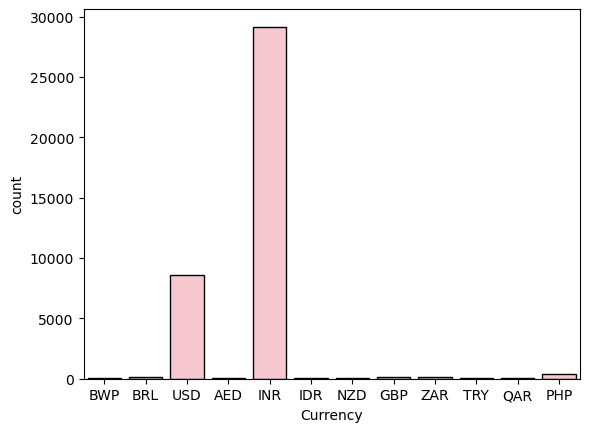

In [255]:
# No. of counts based on Currency
sns.countplot(data = final_df, x = 'Currency', edgecolor = 'black', color = 'pink')

# Graph tells 70% of restaurants belongs to India 

In [271]:
# Top 5 cities have more number of restaurants 

final_df.groupby('City')['City'].value_counts().sort_values(ascending = False).head()

City
New Delhi    17835
Noida         3965
Gurgaon       3170
Guwahati       613
Faridabad      580
Name: count, dtype: int64

In [279]:
# Top 5 Cuisiness 
final_df.groupby('Cuisines')['Cuisines'].value_counts().sort_values(ascending = False).head()

Cuisines
North Indian             2898
North Indian, Chinese    1365
Cafe                     1194
North Indian, Mughlai    1117
Chinese                   869
Name: count, dtype: int64

/tmp/ipykernel_8157/2372670884.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = final_df, x = 'Has Table booking', palette = 'viridis')


<Axes: xlabel='Has Table booking', ylabel='count'>

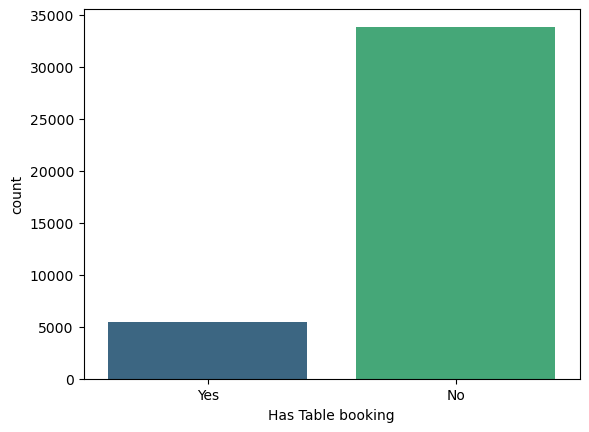

In [301]:
#  Countplot for Table Reservation column
sns.countplot(data = final_df, x = 'Has Table booking', palette = 'viridis')

/tmp/ipykernel_8157/2756628488.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = final_df, x = 'Has Online delivery', palette = 'winter')


<Axes: xlabel='Has Online delivery', ylabel='count'>

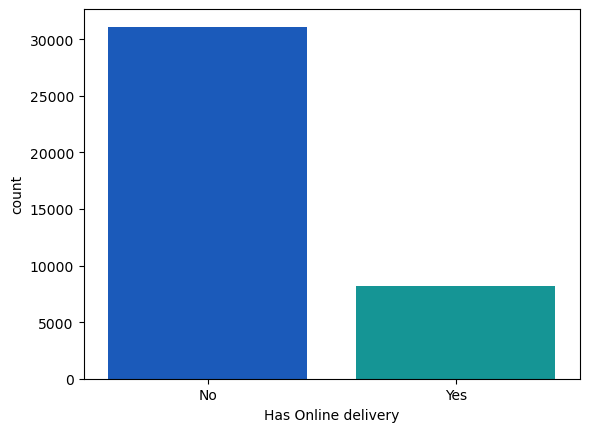

In [302]:
# Countplot for Has Online delivery column
sns.countplot(data = final_df, x = 'Has Online delivery', palette = 'winter')

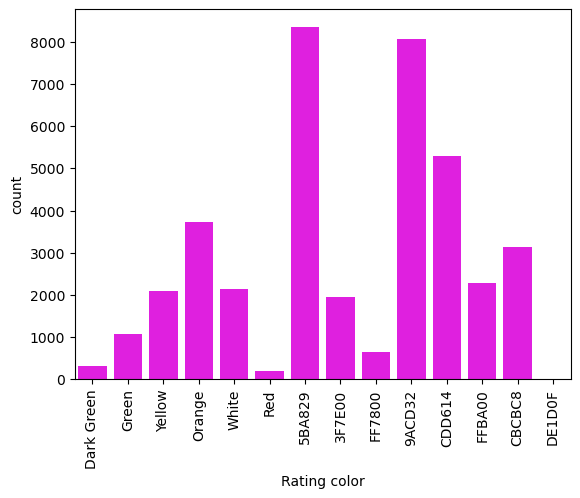

In [298]:
# Countplot for Rating Color
sns.countplot(data=final_df, x='Rating color', color = 'magenta')
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='Rating text', ylabel='count'>

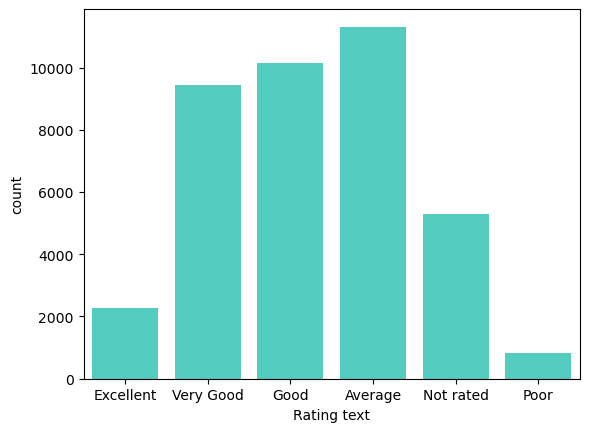

In [300]:
# Countplot for Rating text
sns.countplot(data=final_df, x='Rating text', color = 'turquoise')

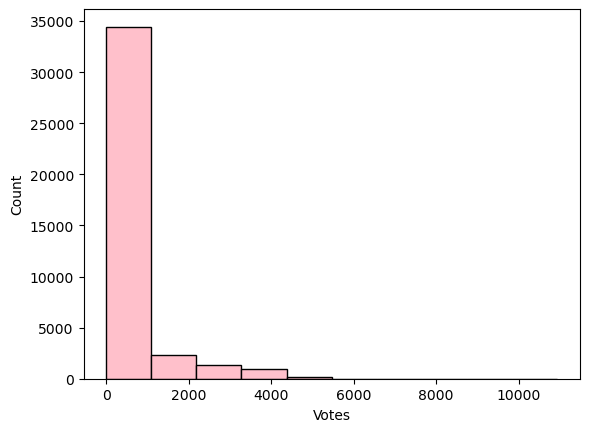

In [316]:
plt.hist(final_df['Votes'], color = 'pink', edgecolor = 'black')
plt.xlabel('Votes')
plt.ylabel('Count')
plt.show()

    BIVARIATE ANALYSIS

In [366]:
final_df.sample()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
2104,18424627,Nosh,1,Gurgaon,"A 222, Supermart 1, DLF Phase 4, Gurgaon","Supermart 1, DLF Phase 4",77.087157,28.462591,"North Indian, Mughlai",700,INR,No,Yes,No,2,4.1,Green,Very Good,103,India


In [321]:
# distribution of restaurants across different countries
final_df.groupby('Country')['Restaurant Name'].count()

Country
Australia          4118
Brazil              120
Canada              746
India             29155
Indonesia           378
New Zealand          80
Phillipines         406
Qatar                40
Singapore           418
South Africa        120
Sri Lanka            40
Turkey               74
UAE                 120
United Kingdom      160
United States      3300
Name: Restaurant Name, dtype: int64

In [340]:
# Which cities have the highest average ratings?

final_df.groupby('City', as_index=False)['Aggregate rating'].mean().sort_values(by='Aggregate rating', ascending=False)

,City,Aggregate rating
57,Inner City,4.900000
108,Quezon City,4.800000
74,Makati City,4.650000
96,Pasig City,4.633333
76,Mandaluyong City,4.625000
...,...,...
98,Paynesville,2.600000
84,Montville,2.400000
79,Mc Millan,2.400000
90,Noida,2.142522


<Axes: xlabel='Rating text'>

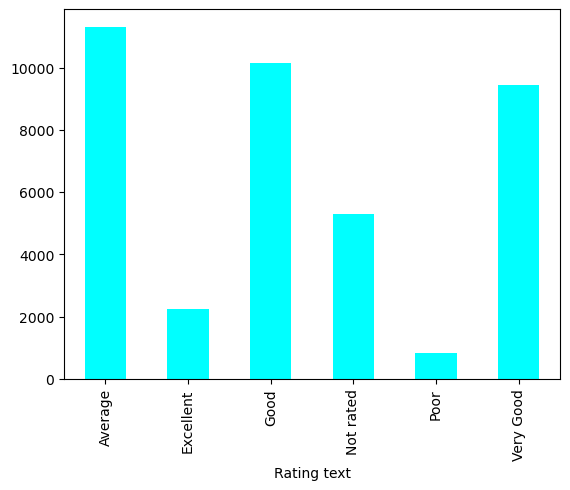

In [346]:
# Is there a relationship between number of votes and rating?

final_df.groupby('Rating text')['Votes'].count().plot(kind = 'bar', color = 'cyan')

In [355]:
# Do highly voted restaurants have better ratings?

final_df[['Votes', 'Aggregate rating']].corr()

,Votes,Aggregate rating
Votes,1.00000,0.35541
Aggregate rating,0.35541,1.00000


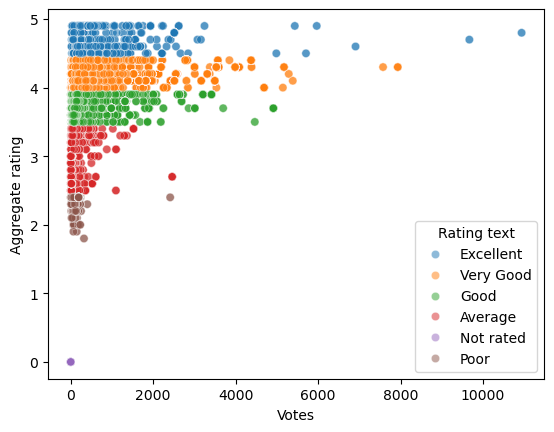

In [358]:
sns.scatterplot(data=final_df, x='Votes', y='Aggregate rating', alpha = 0.5, hue = 'Rating text')
plt.show()

In [363]:
# How does average cost for two vary across countries?
final_df.groupby('Country')['Average Cost for two'].mean()

Country
Australia             24.242836
Brazil               134.666667
Canada                36.461126
India                827.304064
Indonesia         164576.719577
New Zealand           69.750000
Phillipines          909.729064
Qatar                223.750000
Singapore             71.423445
South Africa         419.733333
Sri Lanka           2375.000000
Turkey                86.216216
UAE                  166.416667
United Kingdom        47.812500
United States         23.595455
Name: Average Cost for two, dtype: float64

In [368]:
# Is there a relationship between price range and rating?
final_df[['Price range', 'Aggregate rating']].corr()

,Price range,Aggregate rating
Price range,1.000000,0.472101
Aggregate rating,0.472101,1.000000


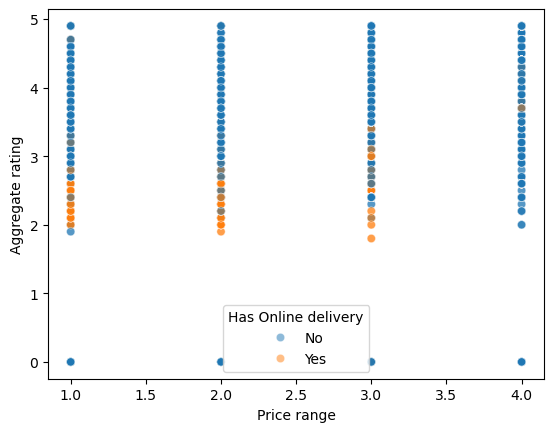

In [374]:
# shows linear relationship but slowly increasing
sns.scatterplot(data=final_df, x='Price range', y='Aggregate rating', alpha = 0.5, hue = 'Has Online delivery')
plt.show()

<Axes: xlabel='Has Table booking'>

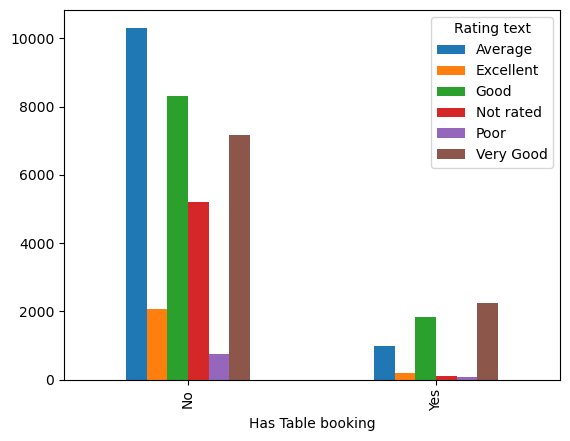

In [382]:
# Does rating text depends on  Table Reservation 
pd.crosstab(df['Has Table booking'], df['Rating text']).plot(kind ='bar')

<Axes: xlabel='Has Table booking', ylabel='Price range'>

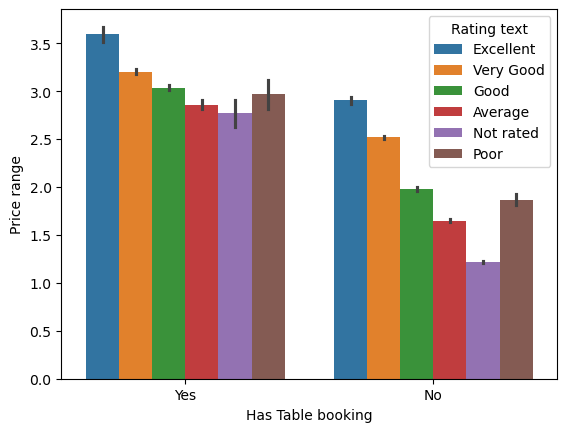

In [388]:
sns.barplot(data = final_df, x = 'Has Table booking', y = 'Price range', hue = 'Rating text')

Text(0.5, 0, 'Price range')

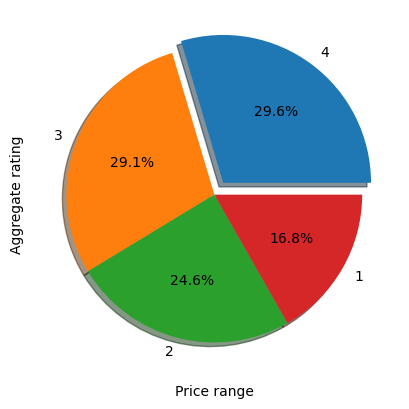

In [417]:
# Do expensive restaurants have better ratings?

final_df.groupby('Price range')['Aggregate rating'].mean().sort_values(ascending = False).plot(kind = 'pie',
                                                                                               autopct = '%0.1f%%',
                                                                                               explode = (0.1, 0, 0, 0), shadow = True )
plt.xlabel('Price range')

In [425]:
# Which countries have the most expensive restaurants?

final_df.groupby('Country')['Average Cost for two'].mean().sort_values(ascending = False)

Country
Indonesia         164576.719577
Sri Lanka           2375.000000
Phillipines          909.729064
India                827.304064
South Africa         419.733333
Qatar                223.750000
UAE                  166.416667
Brazil               134.666667
Turkey                86.216216
Singapore             71.423445
New Zealand           69.750000
United Kingdom        47.812500
Canada                36.461126
Australia             24.242836
United States         23.595455
Name: Average Cost for two, dtype: float64

In [426]:
# Which cuisines are most popular globally?

final_df['Cuisines'].value_counts()

Cuisines
North Indian                   2898
North Indian, Chinese          1365
Cafe                           1194
North Indian, Mughlai          1117
Chinese                         869
                               ... 
Desserts, Börek                   1
Steak, Burger                     1
Italian, Pizza, Fresh Fish        1
Izgara, Steak                     1
Kebab, Turkish Pizza, Döner       1
Name: count, Length: 1832, dtype: int64

In [432]:
# Which cuisines have the highest average ratings?
final_df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending = False).head().index

Index(['Mughlai, Lucknowi', 'American, BBQ, Sandwich', 'Italian, Deli',
       'American, Coffee and Tea', 'American, Caribbean, Seafood'],
      dtype='object', name='Cuisines')

In [444]:
# Do certain cuisines receive more votes than others?

final_df['Cuisines'] = final_df['Cuisines'].str.split(',').explode('Cuisines')
final_df.groupby('Cuisines')['Votes'].sum().sort_values(ascending = False).head()

Cuisines
North Indian     1961568
 Chinese         1335634
 Fast Food        829972
 North Indian     786278
Cafe              676910
Name: Votes, dtype: int64

<Axes: xlabel='Has Online delivery', ylabel='Aggregate rating'>

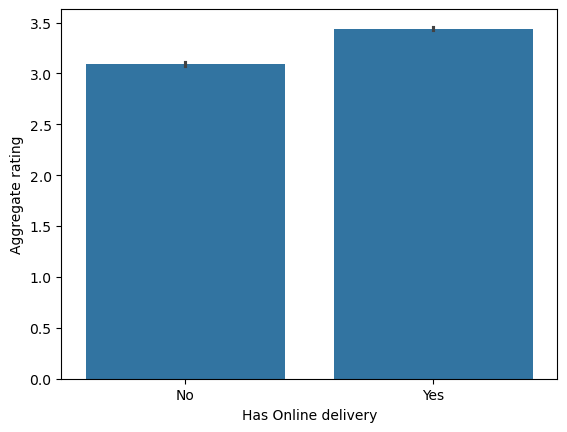

In [445]:
# Do restaurants with online delivery have better ratings?

sns.barplot(data  = final_df, x = 'Has Online delivery', y = 'Aggregate rating')

In [446]:
# Are restaurants currently delivering rated differently from others?

final_df.groupby('Is delivering now')['Aggregate rating'].mean().round(2)

Is delivering now
No     3.17
Yes    3.13
Name: Aggregate rating, dtype: float64

    INSIGHTS

* Most restaurants fall in the mid-rating category, indicating a highly competitive market with similar quality levels.
* Extremely high-rated and low-rated restaurants are rare, showing a balanced rating distribution.
* Restaurant data is heavily concentrated in a few countries, making the dataset geographically imbalanced.
* Smaller cities sometimes show higher ratings due to fewer restaurants, which can lead to biased results.
* Restaurants with a higher number of votes tend to have more reliable and stable ratings.
* High popularity (votes) does not always mean high ratings, but it increases trust in the rating.
* Expensive restaurants generally have slightly better ratings, but the relationship is weak.
* Pricing alone is not a strong indicator of restaurant quality or customer satisfaction.
* Cuisine diversity plays an important role, as restaurants offering multiple cuisines attract more engagement.
* Certain cuisines are more popular and receive significantly higher customer interaction.
* Online delivery availability has only a minor impact on restaurant ratings.
* Restaurants offering table booking tend to provide better service and receive higher ratings.
* Real-time delivery status (whether delivering now or not) has minimal influence on overall ratings.
* Cost comparison across countries is misleading without currency standardization, highlighting the importance of data preprocessing.
* Real-world datasets are highly unstructured and require significant cleaning before meaningful analysis can be performed.